In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from abm.rewards import *
from abm.rewards import _cholesky_grid, dog_rbf_landscape, _min_max
from abm.utils import plot_reward_grids, plot_reward_grid, rbf

# Reward landscape examples

This notebook contains examples from various kinds of reward landscapes:
- Spatially-correlated from Gaussian Process
- Gabor patches
- Difference of Gaussians (DoG)
- Spatially correlated + DoG superimposed

## 1. Correlated Reward Landscapes

We generate correlated reward landscapes where a 'parent' map defines the general structure, and 'children' maps are correlated with it.

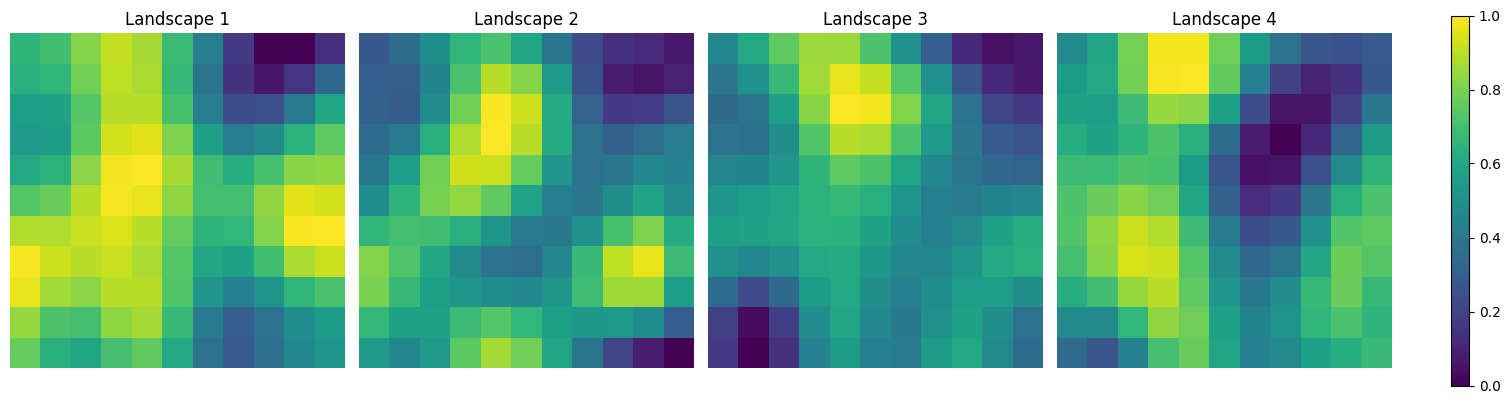

In [16]:
rng = np.random.default_rng(42)
n_children = 3
grid_size = 11

parent, children = make_parent_and_children_cholesky(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    length_scale=2.0
)

plot_reward_grids(np.array([parent] + children))
plt.show()

## 2. Gabor patches
We generate a parent Gabor landscape, and correlated children by generating with a new angle and mixing with parent

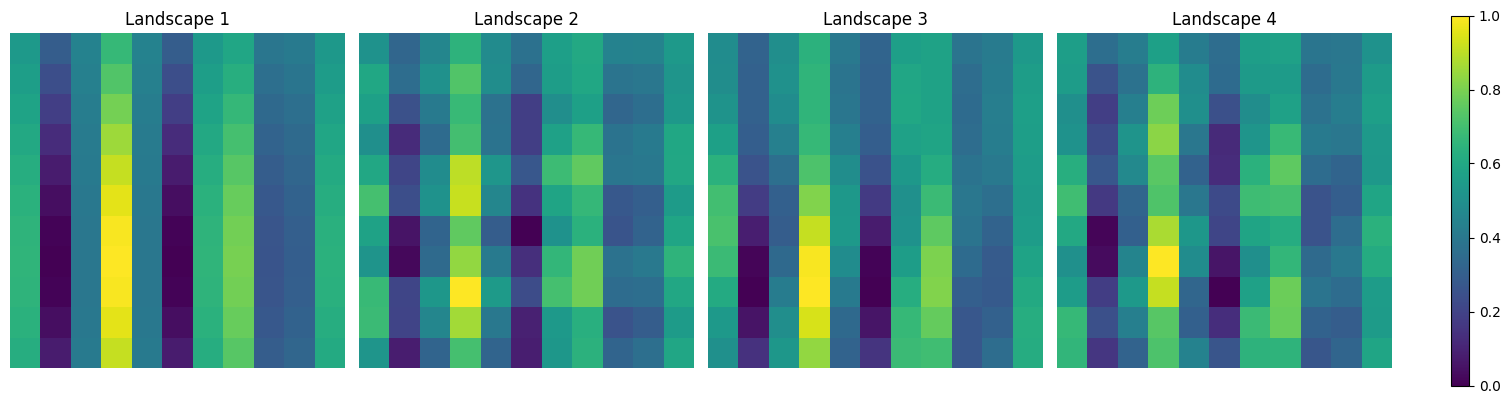

Correlations:


[np.float64(0.9499790754586327),
 np.float64(0.9552422314811077),
 np.float64(0.9495972194988955)]

In [9]:
rng = np.random.default_rng(42)
n_children = 3
grid_size = 11

parent, children = make_parent_and_children_gabor(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    frequency=3,
    sigma=5,
    theta_parent=0,
    phase_parent=0,
    correlation=0.95,
    center=(3.0, 3.0)
)

plot_reward_grids(np.array([parent] + children))
print('Correlations:')
check_correlations(parent, children, target_correlation=0.95, tol=0.1)[1]

## 3. Difference of Gaussians (DoG)
We generate a parent DoG landscape, and correlated children by jitetering parameters

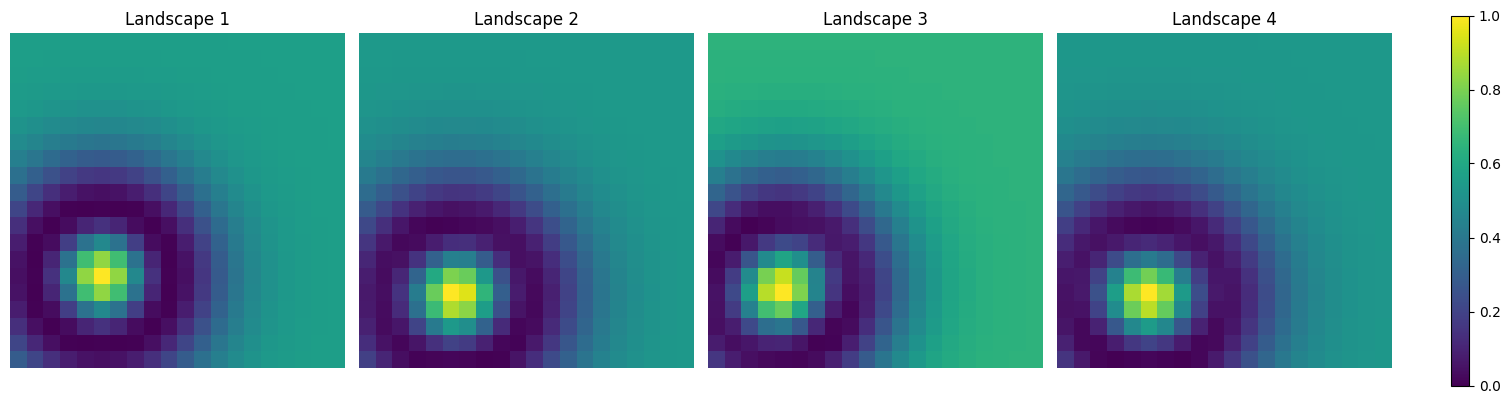

Correlations: [np.float64(0.9), np.float64(0.9000000000000002), np.float64(0.9000000000000002)]


In [43]:
rng = np.random.default_rng(42)
n_children = 3
grid_size = 20

parent, children = make_parent_and_children_mexican_hat(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    # frequency=3,
    sigma_inner=2,
    sigma_outer=4,
    correlation=0.9,
    center=(grid_size//4, grid_size//4)
)

plot_reward_grids(np.array([parent] + children))
print('Correlations:', check_correlations(parent, children, target_correlation=0.9, tol=0.1)[1])

## 4. Correlated DoG
We generate a base spatially-correlated landscape and superimpose a DoG kernel

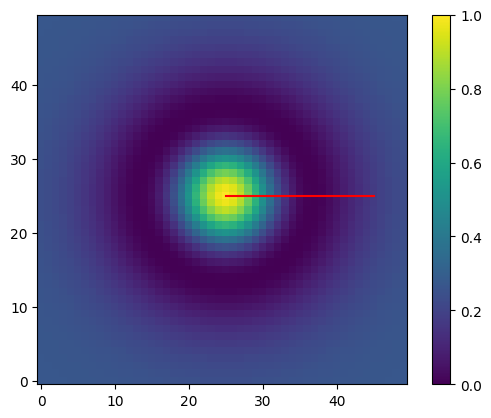

np.float64(0.02842972889667839)

In [50]:
grid_size = 50
dog_rbf = dog_rbf_landscape(grid_size=grid_size, center=(grid_size//2, grid_size//2), lambda_inner=5, lambda_outer=10)
dog_rbf = _min_max(dog_rbf)
plt.imshow(dog_rbf, origin='lower')
plt.plot([25,45],[25,25], color='red')
plt.colorbar()
plt.show()
dog_rbf[35,25]

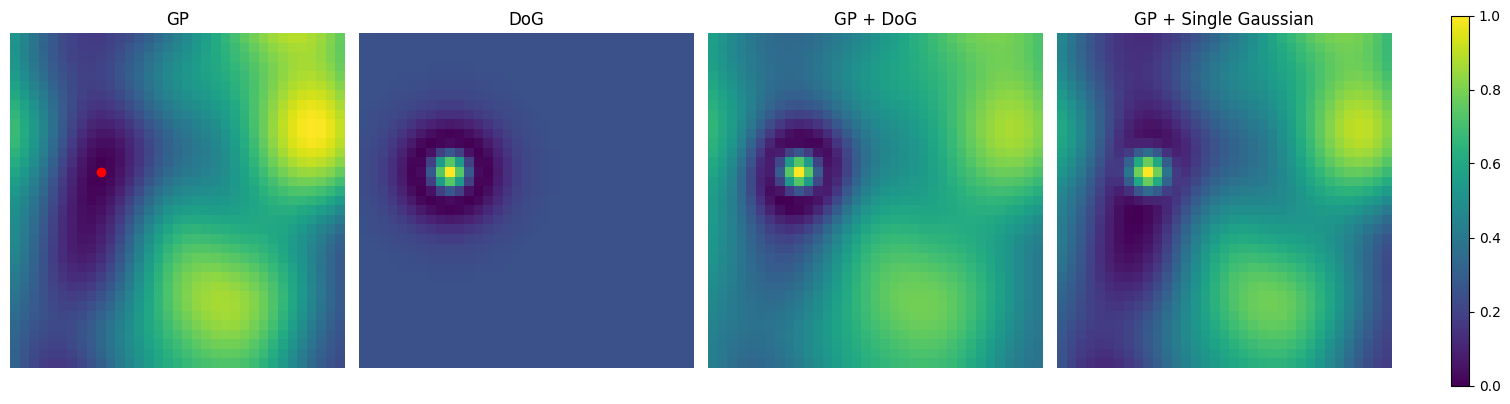

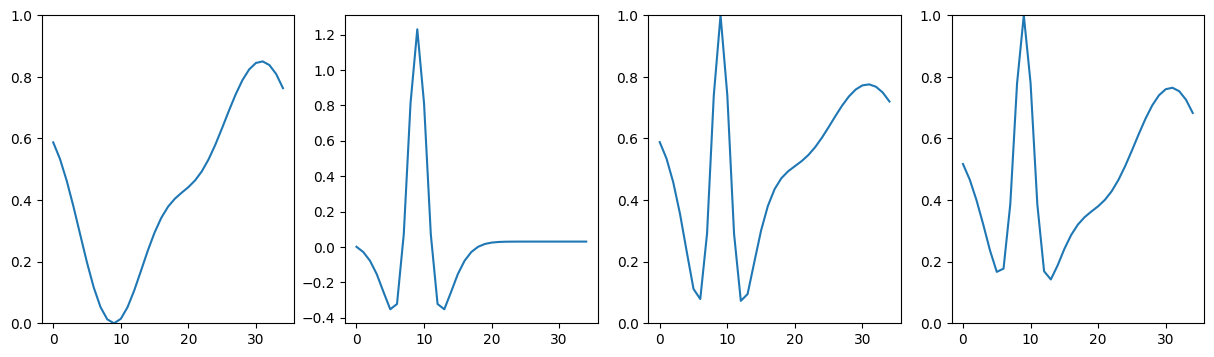

In [51]:
rng = None # np.random.default_rng(42)
grid_size = 35

mix, gp, dog, min_coords = make_correlated_dog(
    rng, 
    grid_size=grid_size,
    length_scale=grid_size / 5
)

# Generate single Gaussian at minimum of GP
single_gauss = rbf(grid_size=grid_size, length_scale=grid_size/25, center=min_coords) * 1.1
gp_gauss = _min_max(gp + single_gauss)

# Plot mixed landscape
fig, ax = plot_reward_grids(np.array([gp, dog, mix, gp_gauss]), titles=['GP', 'DoG', 'GP + DoG', 'GP + Single Gaussian'])
ax[0].plot(min_coords[0], min_coords[1], 'ro')
plt.show()

_, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].plot(gp[min_coords[1],:])
ax[1].plot(dog[min_coords[1],:])
ax[2].plot(mix[min_coords[1],:])
ax[3].plot(gp_gauss[min_coords[1],:])
ax[0].set_ylim(0, 1)
ax[2].set_ylim(0, 1)
ax[3].set_ylim(0, 1)
plt.show()

## 5. Socially correlated correlated DoGs

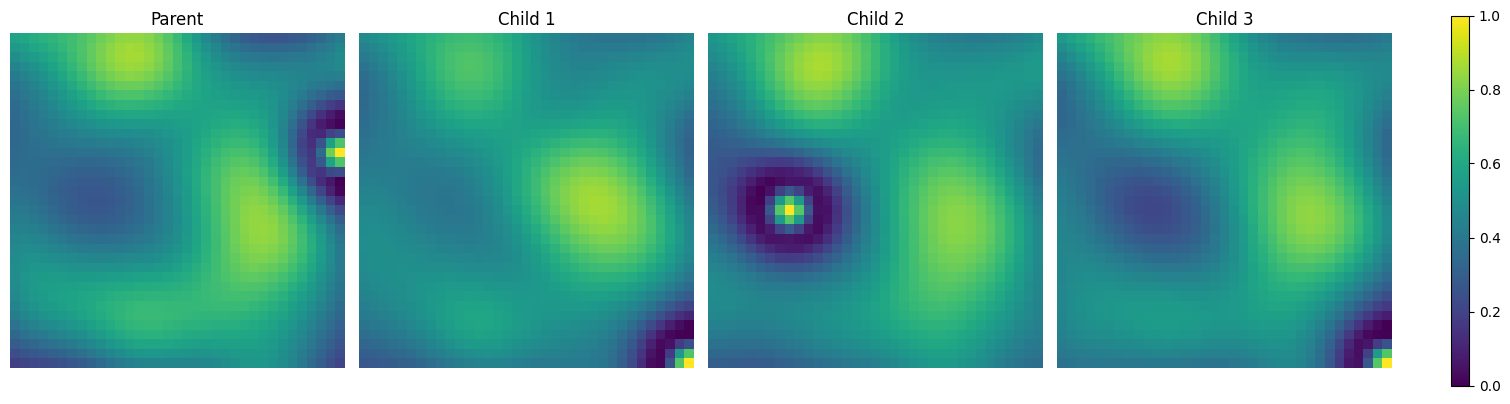

(np.False_,
 [np.float64(0.6937453920538175),
  np.float64(0.743567896596512),
  np.float64(0.7477572319099888)])

In [22]:
rng = None # np.random.default_rng(42)
grid_size = 35
n_children = 3

parent, children, _ = make_parent_and_children_correlated_dog(
    rng, 
    grid_size=grid_size,
    n_children=n_children,
    length_scale=grid_size / 5,
    target_correlation=0.9,
)

plot_reward_grids(np.array([parent] + children), titles=['Parent'] + [f'Child {i+1}' for i in range(n_children)])
plt.show()

check_correlations(parent, children, target_correlation=0.6, tol=0.1)